In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
import threading
import torch.multiprocessing as mp
import copy

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
class SharedActorCritic(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_actions):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.actorHead = nn.Sequential(
            nn.Linear(hidden_dim,num_actions),
            nn.Softmax(dim=-1)
        )

        self.criticHead = nn.Sequential(
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self,x):
        shared_output = self.shared(x)
        actorHead_output = self.actorHead(shared_output)
        criticHead_output = self.criticHead(shared_output)

        return actorHead_output, criticHead_output





In [4]:
model = SharedActorCritic(4,128,2)
model.share_memory()

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [13]:
all_rewards = {0: [], 1: []}
def workers(thread_id, global_model, optimizer, num_episodes, lock, all_rewards):
    env = gym.make('CartPole-v1')

    for episode in range(num_episodes):
        obs,_ = env.reset()

        local_model = copy.deepcopy(global_model)

        log_probs = []
        values = []
        rewards = []


        done = False
        while not done:
            obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
            action_probs, value = local_model(obs_tensor)
            dist = torch.distributions.Categorical(action_probs)
            action = dist.sample()
            prob = dist.log_prob(action)
            log_probs.append(prob)

            values.append(value.squeeze())

            action = action.item()
            obs, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                done = True
        
        returns = []
        R = 0
        gamma = 0.99

        for reward in reversed(rewards):
            R = reward + gamma * R
            returns.insert(0, R)

        returns_tensor = torch.tensor(returns, dtype=torch.float32)
        log_probs_tensor = torch.stack(log_probs)
        values_tensor = torch.stack(values)

        advantage = (returns_tensor - values_tensor).detach()

        actor_loss = -(log_probs_tensor*advantage).mean()
        critic_loss = F.mse_loss(values_tensor,returns_tensor)

        with lock:
            optimizer.zero_grad()

            total_loss = actor_loss + critic_loss
            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(global_model.parameters(), max_norm=0.5)

            optimizer.step()
            all_rewards[thread_id].append(sum(rewards))
            print(f"Thread {thread_id} | Episode {episode} | Reward: {sum(rewards)}")

                        

In [14]:
lock = threading.Lock()
threads = []
for i in range(2):
    t = threading.Thread(target=workers, args=(i, model, optimizer, 300, lock, all_rewards))
    threads.append(t)
    t.start()

for t in threads:
    t.join()



Thread 0 | Episode 0 | Reward: 95.0
Thread 1 | Episode 0 | Reward: 216.0
Thread 0 | Episode 1 | Reward: 145.0
Thread 1 | Episode 1 | Reward: 146.0
Thread 0 | Episode 2 | Reward: 27.0
Thread 1 | Episode 2 | Reward: 126.0
Thread 0 | Episode 3 | Reward: 139.0
Thread 1 | Episode 3 | Reward: 187.0
Thread 0 | Episode 4 | Reward: 119.0
Thread 1 | Episode 4 | Reward: 139.0
Thread 0 | Episode 5 | Reward: 217.0
Thread 1 | Episode 5 | Reward: 103.0
Thread 0 | Episode 6 | Reward: 190.0
Thread 1 | Episode 6 | Reward: 204.0
Thread 0 | Episode 7 | Reward: 28.0
Thread 0 | Episode 8 | Reward: 123.0
Thread 1 | Episode 7 | Reward: 165.0
Thread 0 | Episode 9 | Reward: 148.0
Thread 1 | Episode 8 | Reward: 151.0
Thread 0 | Episode 10 | Reward: 144.0
Thread 1 | Episode 9 | Reward: 98.0
Thread 1 | Episode 10 | Reward: 121.0
Thread 1 | Episode 11 | Reward: 35.0
Thread 0 | Episode 11 | Reward: 381.0
Thread 1 | Episode 12 | Reward: 150.0
Thread 0 | Episode 12 | Reward: 75.0
Thread 1 | Episode 13 | Reward: 192.0


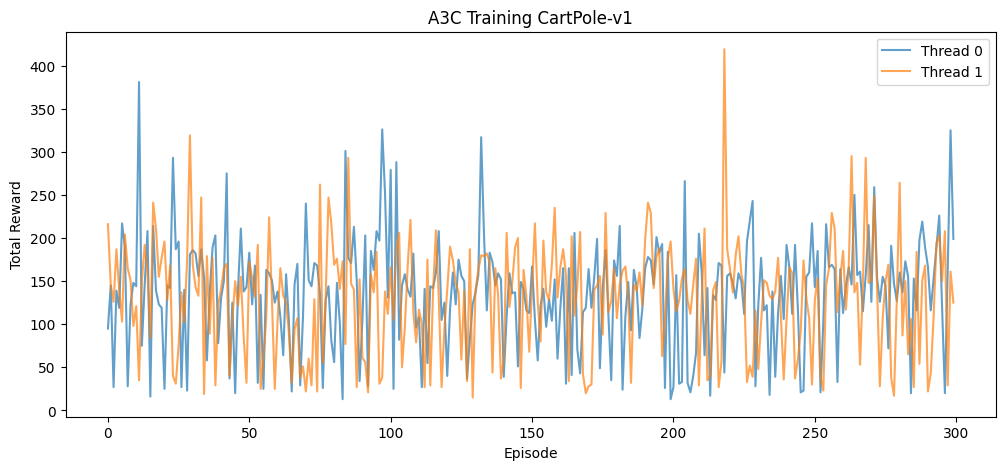

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(all_rewards[0], label='Thread 0', alpha=0.7)
plt.plot(all_rewards[1], label='Thread 1', alpha=0.7)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Training CartPole-v1')
plt.legend()
plt.show()

In [16]:
model.eval()
eval_rewards = []
env = gym.make('CartPole-v1')

for episode in range(10):
    obs, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        obs_tensor = torch.FloatTensor(obs).unsqueeze(0)

        action_probs, value = model(obs_tensor)
        action = torch.argmax(action_probs)
        action = action.item()
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:
            done = True
    
    eval_rewards.append(total_reward)
    print(f"Eval Episode {episode} | Reward: {total_reward}")

Eval Episode 0 | Reward: 166.0
Eval Episode 1 | Reward: 175.0
Eval Episode 2 | Reward: 187.0
Eval Episode 3 | Reward: 159.0
Eval Episode 4 | Reward: 164.0
Eval Episode 5 | Reward: 166.0
Eval Episode 6 | Reward: 191.0
Eval Episode 7 | Reward: 164.0
Eval Episode 8 | Reward: 182.0
Eval Episode 9 | Reward: 166.0


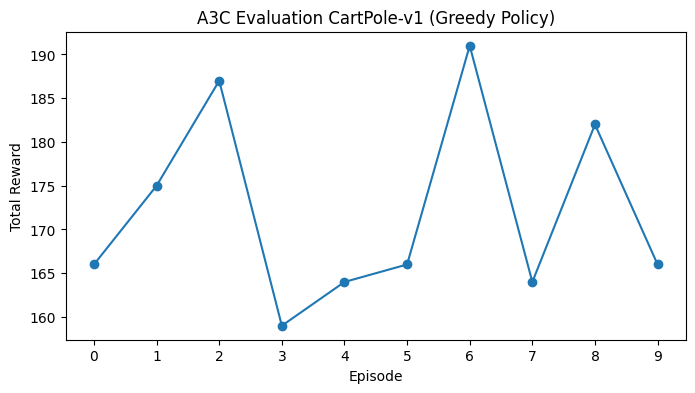

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(eval_rewards, marker='o')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('A3C Evaluation CartPole-v1 (Greedy Policy)')
plt.xticks(range(10))
plt.show()

In [19]:
%pip install "gymnasium[other]"

  Using cached pillow-11.3.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (9.0 kB)
Using cached pillow-11.3.0-cp310-cp310-macosx_11_0_arm64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 6.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 8.6 MB/s  0:00:05m0:00:0100:01
  Attempting uninstall: pillow
    Found existing installation: pillow 12.0.0
    Uninstalling pillow-12.0.0:
      Successfully uninstalled pillow-12.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [moviepy]m3/6 [opencv-python]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
from save_rendered_video import run_and_record_one_episode

def greedy_policy(obs):
    obs_tensor = torch.FloatTensor(obs).unsqueeze(0)
    with torch.no_grad():
        action_probs, _ = model(obs_tensor)
    return torch.argmax(action_probs).item()

run_and_record_one_episode('CartPole-v1', greedy_policy, out_dir='videos')


/opt/homebrew/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /Users/aryaapareshdeshpande/Desktop/Reinforcement Learning/Assignment 3 - Checkpoint attached files Apr 9, 2026 547 PM/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/opt/homebrew/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Saved video in videos. Episode reward: 179.0, steps: 179


In [21]:
torch.save(model.state_dict(), 'a3_part_2_a3c_cartpole_aryaapar.pth')